BEFORE standardization
         age    fare
mean  29.315  32.097
std   12.985  49.698

AFTER standardization
      age_z  fare_z
mean  0.000   0.000
std   1.001   1.001


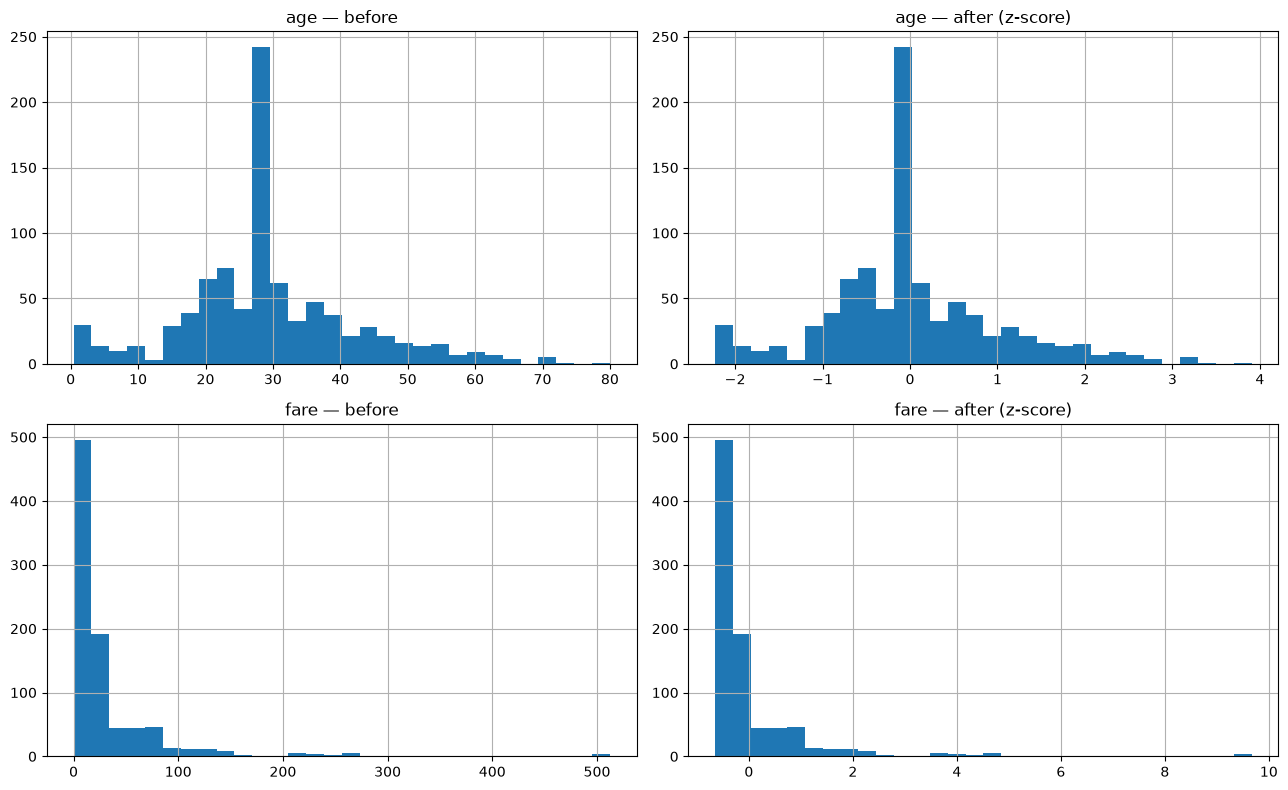

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(df_clean[["age", "fare"]])
scaled_df = pd.DataFrame(scaled, columns=["age_z", "fare_z"])

print("BEFORE standardization")
print(df_clean[["age", "fare"]].agg(["mean", "std"]).round(3).to_string())

print("\nAFTER standardization")
print(scaled_df.agg(["mean", "std"]).round(3).to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
df_clean["age"].hist(ax=axes[0, 0], bins=30);   axes[0, 0].set_title("age — before")
scaled_df["age_z"].hist(ax=axes[0, 1], bins=30); axes[0, 1].set_title("age — after (z-score)")
df_clean["fare"].hist(ax=axes[1, 0], bins=30);   axes[1, 0].set_title("fare — before")
scaled_df["fare_z"].hist(ax=axes[1, 1], bins=30); axes[1, 1].set_title("fare — after (z-score)")
plt.tight_layout()
plt.savefig("plots_standardization.png", dpi=100, bbox_inches="tight")
plt.show()


Applied the z-score `z = (x − mean) / std` to `age` and `fare` using `StandardScaler`.

| Column | Mean before | Std before | Mean after | Std after |
|---|---|---|---|---|
| age | 29.32 | 12.99 | 0.000 | 1.001 |
| fare | 32.10 | 49.70 | 0.000 | 1.001 |

Both columns are now centered at mean ≈ 0 with std ≈ 1, confirming the transform
worked. The before/after histograms show that standardization only rescales the
axis — the distribution shapes are unchanged (fare remains right-skewed). The
slight 1.001 reflects the sample standard deviation (n−1 denominator).

**This is an EDA-stage check only.** It does not feed the modeling pipeline, which
performs its own scaling fit on the training split alone (Task 8) to avoid leakage.

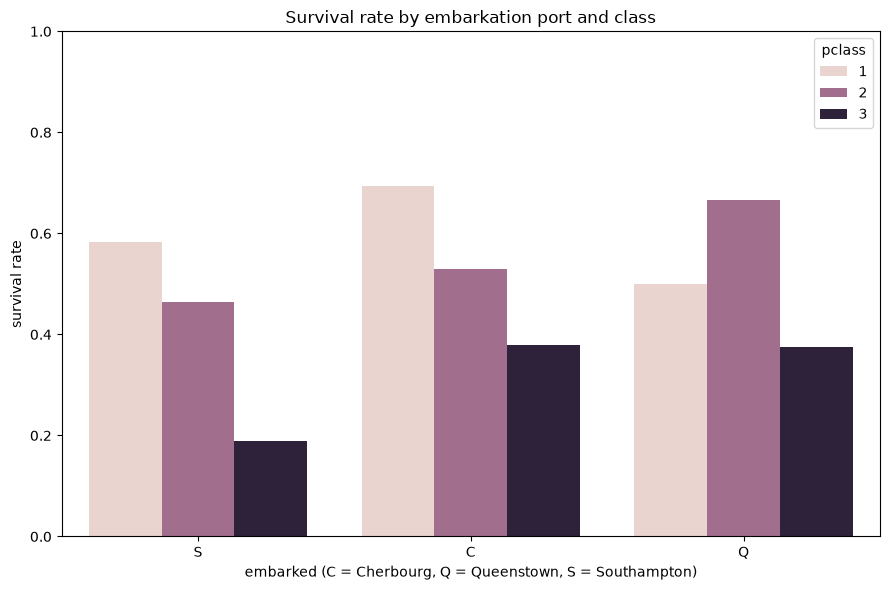

In [19]:
plt.figure(figsize=(9, 6))
sns.barplot(data=df_clean, x="embarked", y="survived", hue="pclass", errorbar=None)
plt.title("Survival rate by embarkation port and class")
plt.xlabel("embarked (C = Cherbourg, Q = Queenstown, S = Southampton)")
plt.ylabel("survival rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("plots_story_4_embarked.png", dpi=100, bbox_inches="tight")
plt.show()

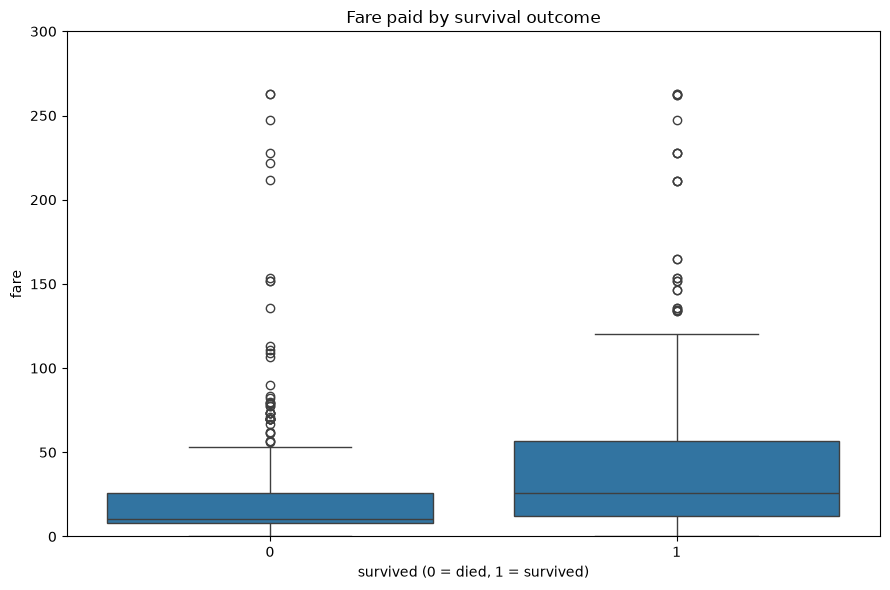

In [18]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_clean, x="survived", y="fare")
plt.title("Fare paid by survival outcome")
plt.xlabel("survived (0 = died, 1 = survived)")
plt.ylabel("fare")
plt.ylim(0, 300)
plt.tight_layout()
plt.savefig("plots_story_3_fare.png", dpi=100, bbox_inches="tight")
plt.show()

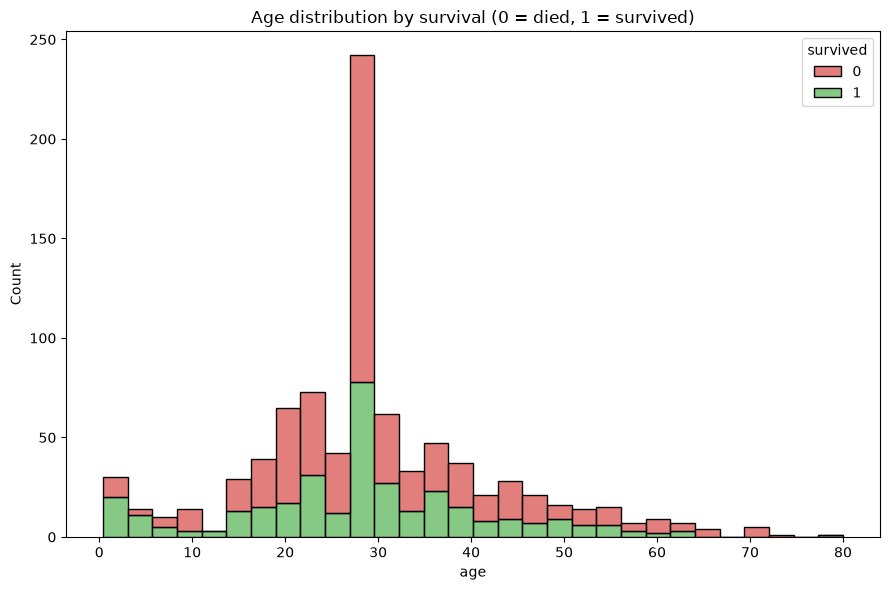

In [17]:
plt.figure(figsize=(9, 6))
sns.histplot(data=df_clean, x="age", hue="survived", bins=30,
             multiple="stack", palette=["#d9534f", "#5cb85c"])
plt.title("Age distribution by survival (0 = died, 1 = survived)")
plt.xlabel("age")
plt.tight_layout()
plt.savefig("plots_story_2_age.png", dpi=100, bbox_inches="tight")
plt.show()

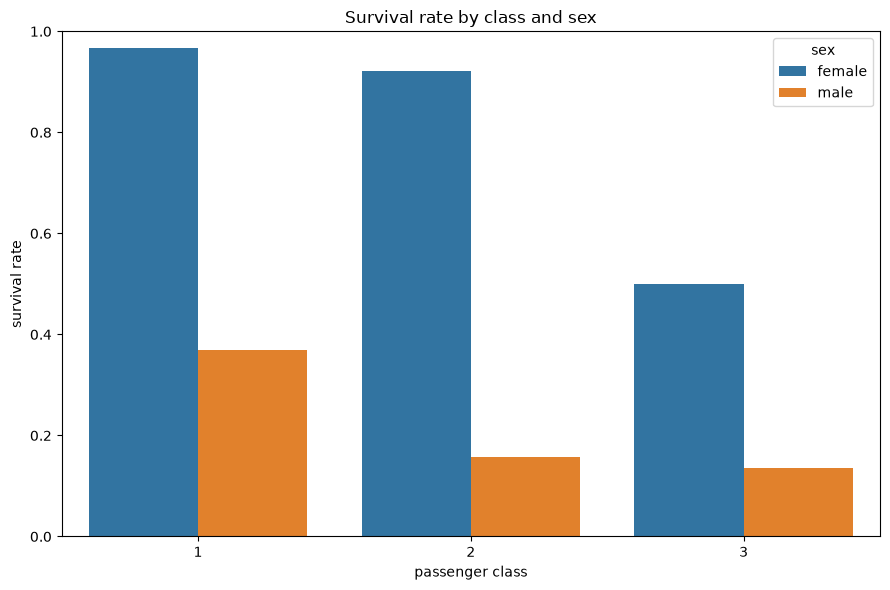

In [16]:
plt.figure(figsize=(9, 6))
sns.barplot(data=df_clean, x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("Survival rate by class and sex")
plt.ylabel("survival rate")
plt.xlabel("passenger class")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("plots_story_1_sex_class.png", dpi=100, bbox_inches="tight")
plt.show()

### Chart 1 — Survival by class and sex

Sex is the single strongest driver of survival, and it holds across every class.
Female survival (blue) towers over male survival (orange) in all three classes —
96.7% vs 36.9% in first class, and even in third class women (50%) outlived first-class
men (37%). Class then modulates the effect within each sex: a female passenger's odds
fall from 97% to 50% as class drops, and a male's from 37% to 14%. The takeaway is
that "women first" dominated, with class as a secondary amplifier.

### Chart 2 — Age distribution by survival

Survival (green) is proportionally highest among the youngest passengers — the 0–10
age bins are mostly green, consistent with "children first." Among adults, deaths (red)
dominate, especially in the 20–40 range where most passengers sat. The tall red-heavy
spike at 28 is the median-imputed age group; because those values are synthetic, this
bar should be read with caution rather than as a real mortality peak.

### Chart 3 — Fare paid by survival

Survivors paid visibly more. The survivor box (right) is shifted well above the
non-survivor box (left): its median fare (~26) is roughly double the deceased's (~10),
and its whole interquartile range sits higher. Since fare is a proxy for class and
cabin location, this reinforces that wealthier passengers had better access to lifeboats.

### Chart 4 — Survival by embarkation port and class

Within every port, survival still falls steeply with class — so class, not port, is the
real driver. Cherbourg (C) passengers show the highest overall survival, but Chart 1's
logic explains why: C boarded a larger share of first-class passengers, so the port
effect is mostly a class effect in disguise. This is a useful reminder that a raw
port-level survival difference is confounded by class composition.

In [15]:
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], corr.iloc[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

print("All off-diagonal pairs ranked by |correlation|:")
for a, b, c in pairs_sorted:
    print(f"  {a:9s} <-> {b:9s}: {c:+.3f}")

print("\nTWO STRONGEST:")
for a, b, c in pairs_sorted[:2]:
    print(f"  {a} <-> {b} = {c:+.3f}")

All off-diagonal pairs ranked by |correlation|:
  pclass    <-> fare     : -0.548
  sibsp     <-> parch    : +0.415
  pclass    <-> age      : -0.337
  survived  <-> pclass   : -0.336
  survived  <-> fare     : +0.255
  age       <-> sibsp    : -0.233
  parch     <-> fare     : +0.218
  age       <-> parch    : -0.171
  sibsp     <-> fare     : +0.161
  age       <-> fare     : +0.094
  survived  <-> parch    : +0.083
  pclass    <-> sibsp    : +0.082
  survived  <-> age      : -0.070
  survived  <-> sibsp    : -0.034
  pclass    <-> parch    : +0.017

TWO STRONGEST:
  pclass <-> fare = -0.548
  sibsp <-> parch = +0.415


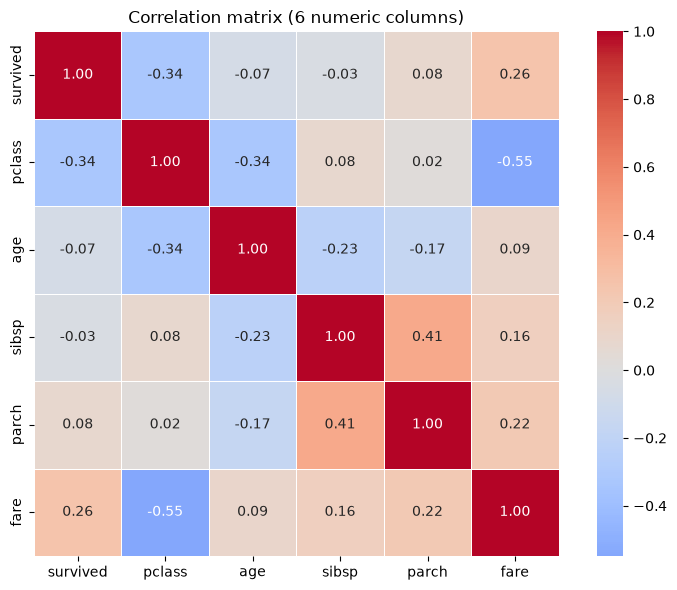

          survived  pclass   age  sibsp  parch  fare
survived      1.00   -0.34 -0.07  -0.03   0.08  0.26
pclass       -0.34    1.00 -0.34   0.08   0.02 -0.55
age          -0.07   -0.34  1.00  -0.23  -0.17  0.09
sibsp        -0.03    0.08 -0.23   1.00   0.41  0.16
parch         0.08    0.02 -0.17   0.41   1.00  0.22
fare          0.26   -0.55  0.09   0.16   0.22  1.00


In [13]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Correlation matrix (6 numeric columns)")
plt.tight_layout()
plt.savefig("plots_correlation_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

print(corr.round(2).to_string())

In [14]:
print("Survival rate by SEX")
for s in df_clean["sex"].unique():
    mask = df_clean["sex"] == s
    rate = df_clean[mask]["survived"].mean()
    print(f"  {s:8s}: {rate:.3f}  ({rate*100:.1f}%)")

# (b) by pclass
print("\nSurvival rate by PCLASS")
for p in sorted(df_clean["pclass"].unique()):
    mask = df_clean["pclass"] == p
    rate = df_clean[mask]["survived"].mean()
    print(f"  class {p}: {rate:.3f}  ({rate*100:.1f}%)")

# (c) by sex AND pclass together (using & to combine masks)
print("\nSurvival rate by SEX + PCLASS")
for s in df_clean["sex"].unique():
    for p in sorted(df_clean["pclass"].unique()):
        mask = (df_clean["sex"] == s) & (df_clean["pclass"] == p)
        rate = df_clean[mask]["survived"].mean()
        print(f"  {s:8s} class {p}: {rate:.3f}  ({rate*100:.1f}%)  n={mask.sum()}")

Survival rate by SEX
  male    : 0.189  (18.9%)
  female  : 0.740  (74.0%)

Survival rate by PCLASS
  class 1: 0.626  (62.6%)
  class 2: 0.473  (47.3%)
  class 3: 0.242  (24.2%)

Survival rate by SEX + PCLASS
  male     class 1: 0.369  (36.9%)  n=122
  male     class 2: 0.157  (15.7%)  n=108
  male     class 3: 0.135  (13.5%)  n=347
  female   class 1: 0.967  (96.7%)  n=92
  female   class 2: 0.921  (92.1%)  n=76
  female   class 3: 0.500  (50.0%)  n=144


### Survival rates

**By sex:**
| Sex | Survival rate |
|---|---|
| Female | 74.0% |
| Male | 18.9% |

**By passenger class:**
| Class | Survival rate |
|---|---|
| 1st | 62.6% |
| 2nd | 47.3% |
| 3rd | 24.2% |

**By sex and class together:**
| Group | Survival rate | n |
|---|---|---|
| Female, 1st | 96.7% | 92 |
| Female, 2nd | 92.1% | 76 |
| Female, 3rd | 50.0% | 144 |
| Male, 1st | 36.9% | 122 |
| Male, 2nd | 15.7% | 108 |
| Male, 3rd | 13.5% | 347 |

The combined breakdown is the clearest signal in the dataset: a first-class woman
had a **96.7%** chance of survival, a third-class man only **13.5%** — a near-7×
gap. Sex is the dominant factor (74% vs 18.9%), with class amplifying it within
each sex. This reflects the "women and children first" evacuation policy, reinforced
by first-class passengers' better access to lifeboats.

### Correlation matrix — two strongest pairs

Ranked by absolute off-diagonal coefficient, the two strongest correlations are:

1. **`pclass ↔ fare` = −0.548.** Negative because class is coded so that 1st class
   is the *lowest* number but the *most expensive* — as the class number rises
   (1 → 3), fare falls. It simply encodes "higher classes cost more" on an inverted
   scale, not a survival relationship.

2. **`sibsp ↔ parch` = +0.415.** Positive: passengers travelling with siblings or a
   spouse also tended to have parents or children aboard — families travelled together
   as units.

Note that neither top pair directly involves `survived`. The strongest survival
links are `survived ↔ pclass` (−0.34) and `survived ↔ fare` (+0.26), confirming
that wealth and class predicted survival — but by the rubric's definition (largest
absolute coefficient), the two structural pairs above rank higher.

In [ ]:
mean_fare = df_clean["fare"].mean()
median_fare = df_clean["fare"].median()
mode_fare = df_clean["fare"].mode()[0]

print(f"Fare mean   = {mean_fare:.2f}")
print(f"Fare median = {median_fare:.2f}")
print(f"Fare mode   = {mode_fare:.2f}")

if mean_fare > median_fare > mode_fare:
    print("\nmean > median > mode  ->  RIGHT-skewed (positive skew)")
elif mean_fare < median_fare < mode_fare:
    print("\nmean < median < mode  ->  LEFT-skewed (negative skew)")
else:
    print("\nno clean ordering  ->  approximately symmetric")

Fare mean   = 32.10
Fare median = 14.45
Fare mode   = 8.05

mean > median > mode  ->  RIGHT-skewed (positive skew)


In [ ]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), round(lower, 2), round(upper, 2)

for col in ["age", "fare"]:
    n, lo, hi = count_outliers(df_clean[col])
    print(f"{col}: {n} outliers  (bounds: [{lo}, {hi}])")

age: 65 outliers  (bounds: [2.5, 54.5])
fare: 114 outliers  (bounds: [-26.76, 65.66])


C:\Users\KVR DELL\AppData\Local\Temp\ipykernel_30080\3484092811.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(df_clean["age"], vert=False)
C:\Users\KVR DELL\AppData\Local\Temp\ipykernel_30080\3484092811.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(df_clean["fare"], vert=False)


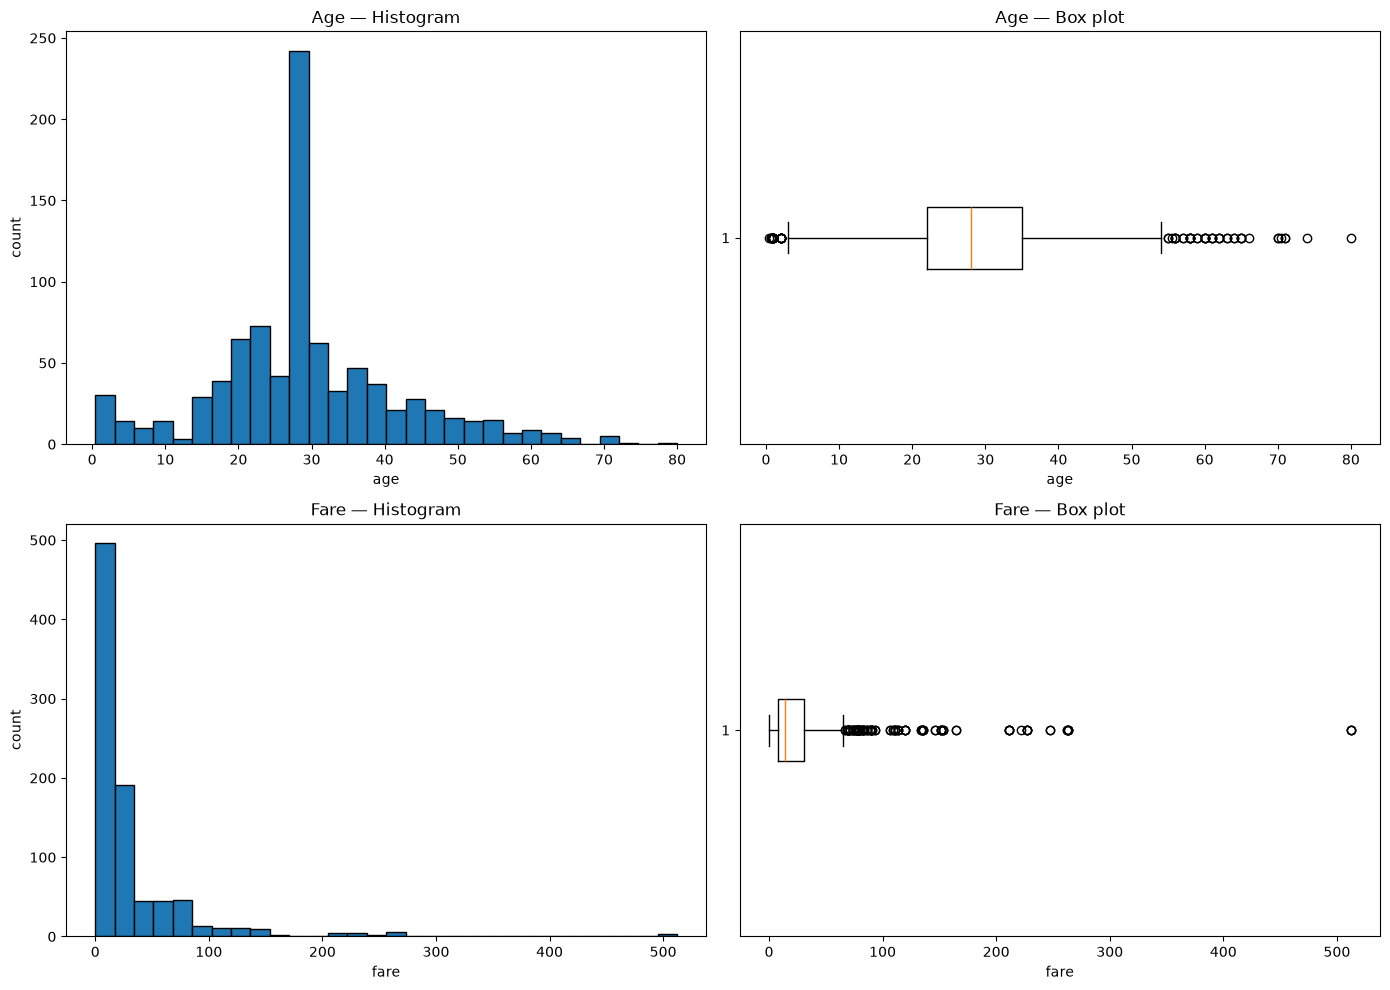

In [10]:
# --- Task 3: univariate analysis of age and fare ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# age
axes[0, 0].hist(df_clean["age"], bins=30, edgecolor="black")
axes[0, 0].set_title("Age — Histogram")
axes[0, 0].set_xlabel("age"); axes[0, 0].set_ylabel("count")

axes[0, 1].boxplot(df_clean["age"], vert=False)
axes[0, 1].set_title("Age — Box plot")
axes[0, 1].set_xlabel("age")

# fare
axes[1, 0].hist(df_clean["fare"], bins=30, edgecolor="black")
axes[1, 0].set_title("Fare — Histogram")
axes[1, 0].set_xlabel("fare"); axes[1, 0].set_ylabel("count")

axes[1, 1].boxplot(df_clean["fare"], vert=False)
axes[1, 1].set_title("Fare — Box plot")
axes[1, 1].set_xlabel("fare")

plt.tight_layout()
plt.savefig("plots_age_fare_univariate.png", dpi=100, bbox_inches="tight")
plt.show()

## Task 3 — Univariate analysis: age and fare

### Outlier counts (IQR rule)

Outliers are values outside `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.

| Column | Outliers | IQR bounds |
|---|---|---|
| `age` | 65 | [2.5, 54.5] |
| `fare` | 114 | [−26.76, 65.66] |

For `fare`, the lower bound is negative because the distribution is heavily
right-skewed; since no fare is below 0, all 114 outliers fall on the upper end
(the expensive first-class tickets).

### Age distribution

Age is roughly symmetric, centred around the late 20s. The tall spike at 28 is
an artifact of median imputation — the 177 missing ages were all filled with the
median (28.0), which piles onto a single bar. The 65 outliers sit at both
extremes: very young children and elderly passengers.

### Fare skewness

| Statistic | Value |
|---|---|
| Mean | 32.10 |
| Median | 14.45 |
| Mode | 8.05 |

The ordering **mean (32.10) > median (14.45) > mode (8.05)** is the signature of
a **right-skewed (positive skew)** distribution. Most passengers paid a low fare,
while a small number of expensive tickets (up to 512) pull the mean well above
the median. This matches the histogram, which shows a tall cluster at low fares
and a long thin tail to the right.

## Task 2 — Missing-value handling

Measured missing percentages and the strategy applied under the threshold rule
(<5% → drop rows, 5–30% → impute, very high → drop column):

| Column | Missing % | Decision |
|---|---|---|
| `deck` | 77.22% | Dropped column — too sparse to impute reliably |
| `age` | 19.87% | Imputed with median (28.0) — robust to skew |
| `embarked` | 0.22% | Dropped the 2 affected rows |
| `embark_town` | 0.22% | Same 2 rows |

In [7]:
df_clean = df.copy()

df_clean = df_clean.drop(columns=["deck"])

df_clean = df_clean.dropna(subset=["embarked"])

age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

print(f"Age imputed with median = {age_median}")
print(f"Shape after cleaning: {df_clean.shape}")
print("\nRemaining missing values:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("(empty above = no missing values remain)")

Age imputed with median = 28.0
Shape after cleaning: (889, 14)

Remaining missing values:
Series([], dtype: int64)
(empty above = no missing values remain)


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

In [3]:
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)
print(f"Loaded and saved titanic.csv -- shape: {df.shape}")

Loaded and saved titanic.csv -- shape: (891, 15)


In [4]:
print(df.shape)
df.info()
print(df.describe())

(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
         survived      pclass         age       sibsp       parch        fare
count 

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
report = report[report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print(report.to_string())

             missing_count  missing_pct
deck                   688        77.22
age                    177        19.87
embarked                 2         0.22
embark_town              2         0.22


In [6]:
counts = df["survived"].value_counts()
pct = df["survived"].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({"count": counts, "pct": pct}).to_string())

          count    pct
survived              
0           549  61.62
1           342  38.38
